# Classical Imports

In [2]:
import numpy as np
import torch 
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.nn.functional as F

# Data understanding and clusterring 

#  Step 1: Load the data

In [3]:
data = np.loadtxt("all_time_position.txt")

train_data = data[:300000]
val_data   = data[300000:490000]
test_data = data[490000:500000]

In [4]:
# Extract x and y
x = data[:, 0]
y = data[:, 1]

# Lets see those three wells .......

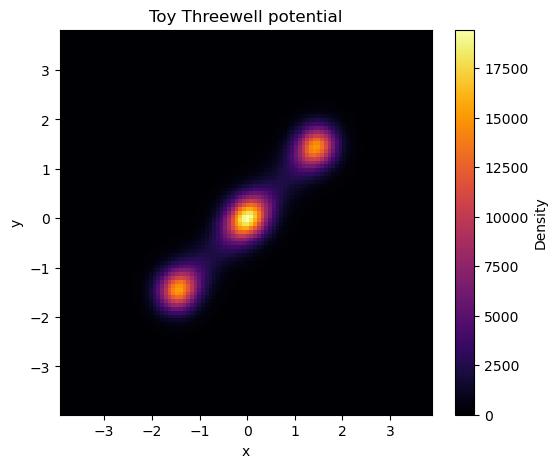

In [5]:
plt.figure(figsize=(6,5))

# 2D histogram 

plt.hist2d(x, y, bins=100, cmap="inferno") 

# Other Cmap options to see cool plot

#plt.hist2d(x, y, bins=100, cmap="rainbow")
#cmap="plasma"    # purple to yellow
#cmap="inferno"   # dark to fiery
#cmap="magma"     # dark purple to orange
#cmap="jet"       # rainbow 

plt.colorbar(label="Density")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Toy Threewell potential")

plt.show()

# Lets perform K means cluserring to get discrete trajectory

In [6]:
from sklearn.cluster import KMeans

# Perform K-means clustering with 3 clusters

##  Stack x and y into a 2D array for clustering

In [8]:

X = np.column_stack((x, y)) 
print(X.shape)

(5000001, 2)


# # 3 clusters (0, 1, and 2)

In [9]:
kmeans = KMeans(n_clusters=3,random_state=42)  
kmeans.fit(X)

KMeans(n_clusters=3, random_state=42)

## k means gives you numeric labels , so lets convert them into letters as 0: 'a', 1: 'b', 2: 'c'

In [12]:

# numeric labels
labels = kmeans.labels_
centers = kmeans.cluster_centers_

# sort clusters by x-coordinate , this is to have a continuity

order = np.argsort(centers[:, 0])

# map ordered labels --> a, b, c
label_map = {order[0]: 'a', order[1]: 'b', order[2]: 'c'}
ordered_labels = np.vectorize(label_map.get)(labels)


print(ordered_labels)

['b' 'b' 'b' ... 'c' 'c' 'c']


# Clusterred plot

/usr/lib/python3/dist-packages/IPython/core/pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


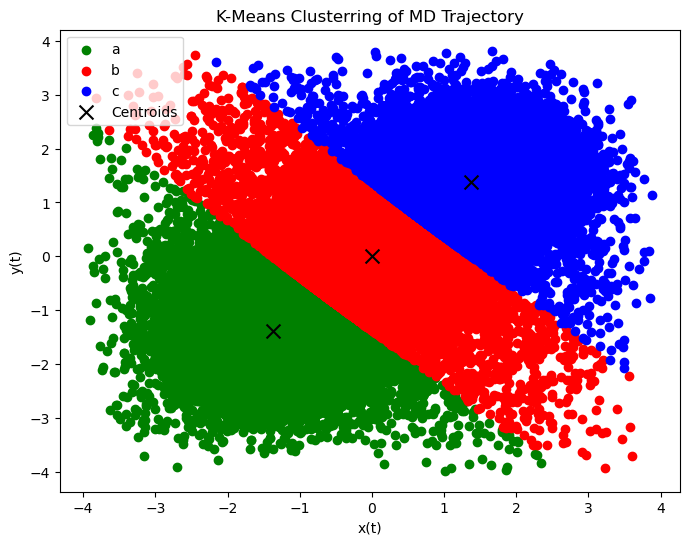

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

# loop through named clusters
for name, color in zip(['a', 'b', 'c'], ['green', 'red', 'blue']):
    plt.scatter(
        x[ordered_labels == name],
        y[ordered_labels == name],
        color=color,
        label=name
    )

# plot centroids
plt.scatter(centers[:, 0], centers[:, 1],
            color='black', marker='x', s=100, label='Centroids')

plt.xlabel("x(t)")
plt.ylabel("y(t)")
plt.title("K-Means Clusterring of MD Trajectory")
plt.legend()
plt.show()

# Save Clusterred trajectory for Modelling 

In [14]:
np.savetxt("cluster_traj.txt", ordered_labels, fmt='%s')

print("Saved cluster labels to cluster_traj.txt")

Saved cluster labels to cluster_traj.txt


# We are Ready with Language Data of trajectory to build a GPT model ..... 

### First things first , a language needs Vocabulary , for our case we have three vocabulary elements 

# Lets Create that Vocabulary 

# Load cluster sequence

In [15]:
data = np.loadtxt("cluster_traj.txt", dtype=str)

# build vocab

- # What happening here is , it is creating a set(data) i.e, set of unique labels 
- # Then list is converted into list for computational ease
- # Finally list is sorted (algorithemically sorted list are best at work)
- # So Vocabulary is a sorted list of set of unique words in the text data

In [16]:
set_of_data = set(data)
set_to_list = list(set_of_data)
sorted_list = sorted(set_to_list)

vocab = sorted_list

print(vocab)

['a', 'b', 'c']


# Assigining numerical representations to the characters in the vocab
## Because at the end of the data , we need numbers for computations , thats what computer understands

# Strings to integer mapping 

In [17]:
string_to_integer = {ch:i for i,ch in enumerate(vocab)} # mapping (stoi)
print(string_to_integer)

{'a': 0, 'b': 1, 'c': 2}


# Integer to strings mapping 

In [18]:
# Inverse mapping (itos)
integers_to_strings = {i:ch for ch,i in string_to_integer.items() }

print(integers_to_strings)

{0: 'a', 1: 'b', 2: 'c'}


# encode the characters in the data to integers

In [22]:
tokens = np.array([string_to_integer[ch] for ch in data])
print(tokens)
np.savetxt("train_data.txt", tokens[:400000], fmt='%s')
np.savetxt("val_data.txt",tokens[400000:490000],fmt='%s')
np.savetxt("prompt.txt",tokens[490000:500000],fmt='%s')


vocab_size = len(vocab)
print(vocab_size)  # 3

[1 1 1 ... 2 2 2]
3


# Save Vocab for future use i.e to use during generation

In [16]:
import json

# save stoi (string --> index)
with open("vocab_stoi.json", "w") as f:
    json.dump(string_to_integer, f, indent=4)

# save itos (index --> string)
# (convert keys to string because JSON doesn't support int keys well)
itos_str = {str(k): v for k, v in integers_to_strings.items()}

with open("vocab_itos.json", "w") as f:
    json.dump(itos_str, f, indent=4)

# Create the dataset .... 

In [17]:
SEQ_LEN = 32

def create_dataset(tokens):
    X, Y = [], []
    for i in range(len(tokens) - SEQ_LEN):
        X.append(tokens[i:i+SEQ_LEN])
        Y.append(tokens[i+1:i+SEQ_LEN+1])
    return np.array(X), np.array(Y)

X, Y = create_dataset(tokens)

In [18]:
for i in range(1):
    print(f"Sample {i}")
    print("X:", X[i])
    print("Y:", Y[i])
    print()

Sample 0
X: [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
Y: [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0]



# Create a Batched dataset for training 

In [19]:
import torch
from torch.utils.data import TensorDataset, DataLoader

# Convert X and Y to tensors for computational ease

X = torch.tensor(X, dtype=torch.long)
Y = torch.tensor(Y, dtype=torch.long)


dataset = TensorDataset(X, Y)
loader = DataLoader(dataset, batch_size=32, shuffle=True)

# iterate
for xb, yb in loader:
    print(xb.shape, yb.shape)
    break

torch.Size([32, 32]) torch.Size([32, 32])


# torch.Size([32, 128]) torch.Size([32, 128])
- # This means , there are 32 paired (X,Y) samples , selected from data randomly to preserve iid 

# Lets Build GPT (Q, K, V + causal attention)

In [20]:
# Set device (This is important as all computations are done and saved on device)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Leo,  We are using : " , DEVICE, "for computation")

Leo,  We are using :  cuda for computation


# Attention block ... 

In [21]:
class CausalSelfAttention(nn.Module):
    def __init__(self, embed_dim):
        super().__init__()
        
        self.q = nn.Linear(embed_dim, embed_dim)
        self.k = nn.Linear(embed_dim, embed_dim)
        self.v = nn.Linear(embed_dim, embed_dim)

        self.scale = embed_dim ** -0.5

    def forward(self, x):
        B, T, C = x.shape

        Q = self.q(x)
        K = self.k(x)
        V = self.v(x)

        # raw attention (no mask)
        attn = Q @ K.transpose(-2, -1) * self.scale
        self_attn = F.softmax(attn, dim=-1)

        # causal mask
        mask = torch.tril(torch.ones(T, T)).to(x.device)
        masked_attn = attn.masked_fill(mask == 0, float('-inf'))
        causal_attn = F.softmax(masked_attn, dim=-1)

        out = causal_attn @ V

        return self_attn, causal_attn, out

# HERE OUR BABY GPT 

In [22]:
class MiniGPT(nn.Module):
    def __init__(self, vocab_size, embed_dim=64, seq_len=32):
        super().__init__()

        self.token_embed = nn.Embedding(vocab_size, embed_dim)
        self.pos_embed = nn.Embedding(seq_len, embed_dim)

        self.attn = CausalSelfAttention(embed_dim)

        self.fc = nn.Linear(embed_dim, vocab_size)

    def forward(self, x):
        B, T = x.shape

        tok = self.token_embed(x)
        pos = self.pos_embed(torch.arange(T, device=x.device))

        x = tok + pos

        self_attn, causal_attn, x = self.attn(x)

        logits = self.fc(x)

        return logits

# Visualising self and masked attention for random data 

In [28]:
import matplotlib.pyplot as plt

def plot_attention(attn, title):
    plt.figure(figsize=(5,5))
    plt.imshow(attn[0].detach().cpu().numpy())
    plt.title(title)
    plt.xlabel("Key (past tokens)")
    plt.ylabel("Query (current token)")
    plt.colorbar()
    plt.show()

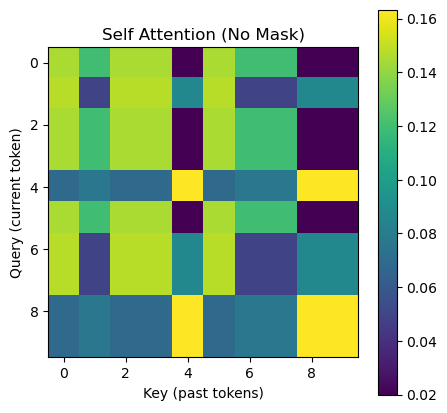

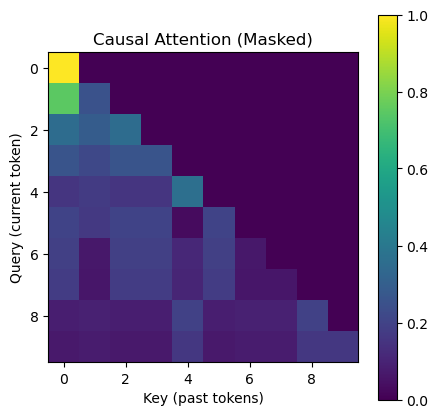

In [29]:
x_sample = torch.randint(0, 3, (1, 10)).to(DEVICE)
model = MiniGPT(vocab_size).to(DEVICE)
x_embed = model.token_embed(x_sample)

self_attn, causal_attn, _ = model.attn(x_embed)

plot_attention(self_attn, "Self Attention (No Mask)")
plot_attention(causal_attn, "Causal Attention (Masked)")

# Training .......

In [ ]:

# dataset + loader
dataset = TensorDataset(X, Y)
loader = DataLoader(dataset, batch_size=8, shuffle=True)

# model
model = MiniGPT(vocab_size).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)



loss_history = []

for epoch in range(200):
    total_loss = 0

    for xb, yb in loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)

        logits = model(xb)

        loss = F.cross_entropy(
            logits.view(-1, vocab_size),
            yb.view(-1)
        )

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(loader)
    loss_history.append(avg_loss)

    if epoch % 20 == 0:
        print(f"Epoch {epoch}, Loss: {avg_loss:.4f}")


Epoch 0, Loss: 0.2088


In [ ]:

np.savetxt("training_loss.txt", loss_history)
print("Saved loss to training_loss.txt")

In [ ]:
torch.save(model.state_dict(), "gpt_cluster_model.pth")
print("Model saved")

# Sampling or generating 

In [ ]:
def generate(model, start_tokens, max_new_tokens=50, seq_len=16, temperature=1.0, device="cpu"):
    model.eval()

    x = torch.tensor(start_tokens, dtype=torch.long).unsqueeze(0).to(device)

    for _ in range(max_new_tokens):
        x_cond = x[:, -seq_len:]

        logits = model(x_cond)
        logits = logits[:, -1, :] / temperature

        probs = F.softmax(logits, dim=-1)
        next_token = torch.multinomial(probs, 1)

        x = torch.cat([x, next_token], dim=1)

    return x.squeeze().cpu().numpy()

In [ ]:
# prompt
start = [0] * 16   

generated = generate(model, start, max_new_tokens=50, seq_len=16, device=DEVICE)
decoded = [itos[i] for i in generated]
print(decoded)
np.savetxt("generated_clusters.txt", decoded, fmt='%s')


In [ ]:
# Generate from saved model

In [ ]:
model = MiniGPT(vocab_size).to(DEVICE)

model.load_state_dict(torch.load("gpt_cluster_model.pth", map_location=DEVICE))
model.eval()

print("Model loaded successfully")

In [ ]:
start = [0] * 16   # or random start

generated = generate(model, start, max_new_tokens=50, seq_len=16, device=DEVICE)

In [ ]:
decoded = [itos[i] for i in generated]
print("Generated sequence:")
print(decoded)

In [ ]:
np.savetxt("generated_clusters.txt", decoded, fmt='%s')